In [1]:
# Importing Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# Reading files into df
df = pd.read_csv("Funnel_Analysis_Data.csv")

In [3]:
df.head()

,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes


In [4]:
df1 = df.copy()

### Total Rows and Columns

In [5]:
# Total Rows and Columns
print("Total Rows:",df1.shape[0])
print("Total Columns:",df1.shape[1])

Total Rows: 21409
Total Columns: 10


### Normalizing columns headers

In [6]:
df1.columns

Index(['User ID', 'Session ID', 'Event Time', 'Event', 'Device', 'Region',
       'Channel', 'Product Category', 'Revenue', 'Bonus Flag'],
      dtype='object')

In [7]:
# Normalize column headers
df1.rename(columns = {"User ID":"user_id","Session ID":"session_id","Event Time":"event_time","Event":"event","Device":"device",
                      "Region":"region","Channel":"channel","Product Category":"product_category","Revenue":"revenue","Bonus Flag":"bonus_flag"}, inplace = True)

### Converting 'event_time' data type to 'datetime64[ns]'

In [8]:
# Converting event_time data type
df1['event_time'] = pd.to_datetime(df1['event_time'])

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21409 entries, 0 to 21408
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           21409 non-null  object        
 1   session_id        21409 non-null  object        
 2   event_time        21409 non-null  datetime64[ns]
 3   event             21409 non-null  object        
 4   device            21409 non-null  object        
 5   region            21409 non-null  object        
 6   channel           21409 non-null  object        
 7   product_category  21409 non-null  object        
 8   revenue           21409 non-null  float64       
 9   bonus_flag        21409 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 1.6+ MB


In [10]:
df1.head()

,user_id,session_id,event_time,event,device,region,channel,product_category,revenue,bonus_flag
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes


### Data Checking


In [11]:
# Checking for nulls

df1.isnull().sum()

,0
user_id,0
session_id,0
event_time,0
event,0
device,0
region,0
channel,0
product_category,0
revenue,0
bonus_flag,0


In [12]:
# Duplicated Values
print("Duplicated Values:",df1.duplicated().sum())

Duplicated Values: 0


### Unique Values

In [13]:
# Unique categories
print("Events:",df1['event'].unique())
print("Devices:",df1['device'].unique())
print("Channels:",df1['channel'].unique())

Events: ['Browse' 'Add to Cart' 'Checkout' 'Purchase']
Devices: ['Tablet' 'Desktop' 'Mobile']
Channels: ['Organic' 'Email' 'Google Ads' 'Social Media']


In [14]:
df1

,user_id,session_id,event_time,event,device,region,channel,product_category,revenue,bonus_flag
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes
...,...,...,...,...,...,...,...,...,...,...
21404,USR-09997,SES-09997,2026-01-03 14:01:06.074656,Checkout,Mobile,North,Google Ads,Sports,0.0,Yes
21405,USR-09998,SES-09998,2025-12-17 06:17:57.577958,Browse,Desktop,North,Social Media,Beauty,0.0,Yes
21406,USR-09998,SES-09998,2025-12-17 06:22:57.577958,Add to Cart,Desktop,North,Social Media,Beauty,0.0,Yes
21407,USR-09999,SES-09999,2025-12-30 15:47:23.983289,Browse,Mobile,East,Email,Sports,0.0,Yes


## KPI's

**Total Unique Users**

In [15]:
print("Unique Users:",df1["user_id"].nunique())

Unique Users: 10000


**Total Purchases**

In [16]:
total_purchase = df1[df1['event'] == 'Purchase']['user_id'].nunique()
print("Total Purchases:",total_purchase)

Total Purchases: 1004


**Total Revenue**

In [17]:
print("Total Revenue:",df1['revenue'].sum())

Total Revenue: 277323.06


**Average Order Value**

In [18]:
purchase_df = df1[df1['event'] == 'Purchase'].copy()
print("Average Order Value:",round(purchase_df['revenue'].mean(),2))

Average Order Value: 276.22


**Overall Conversion**

In [19]:
conversion = 100 * ((df1[df1['event'] == 'Purchase']['user_id'].nunique())/(df1[df1['event']=='Browse']['user_id'].nunique()))
print("Customers Conversion:",round(conversion,2))

Customers Conversion: 10.04


## Device-wise user distribution and Revenue Performance

In [20]:
df1.groupby('device')['user_id'].nunique().sort_values().reset_index(name='user_count')

,device,user_count
0,Mobile,3263
1,Desktop,3366
2,Tablet,3371


User acquisition is almost balanced across devices, with each device contributing to roghly one-third of total users.
This shows no single device dominates customer traffic.

In [21]:
df1['device'].value_counts().reset_index()

,device,count
0,Desktop,7271
1,Tablet,7190
2,Mobile,6948


Here the user distribution is balanced across devices, this shows customers interact with the platform through multiple device rather than one single device.

In [22]:
df1.groupby('device')['revenue'].sum().sort_values(ascending=False).reset_index()

,device,revenue
0,Desktop,98471.83
1,Tablet,94620.13
2,Mobile,84231.10


Desktop users generated the highesr revenue contribution, Tablet users also has generated a similar revenue.
Here it shows that the Desktop users may have stronger purchase intent or good experience throughout the purchasing journey.

## Channel-wise Performance

In [23]:
df1.groupby('channel')['revenue'].sum().sort_values(ascending = False).reset_index()

,channel,revenue
0,Google Ads,73862.32
1,Email,69126.46
2,Social Media,68361.24
3,Organic,65973.04


In [24]:
df1[['region','channel']].value_counts().reset_index().sort_values(['region','count'], ascending =[True,False])

,region,channel,count
0,East,Google Ads,1403
2,East,Email,1379
3,East,Organic,1371
15,East,Social Media,1244
7,North,Organic,1355
10,North,Email,1313
11,North,Google Ads,1303
12,North,Social Media,1297
1,South,Email,1392
5,South,Social Media,1365


### Product Performance


In [25]:
df1[df1['event'] == 'Purchase']['product_category'].value_counts().reset_index()

,product_category,count
0,Electronics,229
1,Fashion,211
2,Beauty,191
3,Sports,189
4,Home,184


Electronics has the highest purchases and Home category has the lowest.

In [26]:
df1.groupby('product_category')['revenue'].sum().sort_values(ascending = False).reset_index(name='revenue')

,product_category,revenue
0,Electronics,62938.46
1,Fashion,58075.22
2,Sports,55856.01
3,Beauty,50353.36
4,Home,50100.01


Electronics generated the highest revenue - $62,938.46, followed by Fashion category at $58,075.22.
Beauty and Home generated the lowest revenue, with both around $50,000.
All Products categories generated revenues that are relatively close, this indicates a balanced customer interest across products.

## User Journey

In [27]:
df1.groupby('event')['user_id'].nunique().sort_values(ascending = False).reset_index(name='count')

,event,count
0,Browse,10000
1,Add to Cart,6949
2,Checkout,3456
3,Purchase,1004


In [28]:
funnel_df = pd.DataFrame({
     'stages': ['Browse','Add to Cart','Checkout','Purchase'],
     'user_count':[10000,6949,3456,1004]
})
fig = px.funnel(funnel_df, x='user_count', y='stages', title = 'Conversion Funnel')
fig.show()

### User Conversions Rate

In [29]:
users = df1.groupby('event')['user_id'].nunique().reset_index()
users

,event,user_id
0,Add to Cart,6949
1,Browse,10000
2,Checkout,3456
3,Purchase,1004


In [30]:
browse = users[users['event'] == 'Browse']['user_id'].values[0]
cart = users[users['event'] == 'Add to Cart']['user_id'].values[0]
checkout = users[users['event'] == 'Checkout']['user_id'].values[0]
purchase = users[users['event'] == 'Purchase']['user_id'].values[0]

In [31]:
cart_rate = (cart/browse)*100
checkout_rate = (checkout/cart) * 100
purchase_rate = (purchase/checkout) * 100
print("Browse to cart rate:",round(cart_rate,2),"%")
print("Cart to Checkout Rate:",round(checkout_rate,2),"%")
print("Checkout to Purchase Rate:", round(purchase_rate,2),"%")

Browse to cart rate: 69.49 %
Cart to Checkout Rate: 49.73 %
Checkout to Purchase Rate: 29.05 %


** Strong browse to cart eonverion rate of 69.49%.
There is a significant user drop off between Cart and Checkout, here 50% if users leave the funnel.
The largest loss occurs during Checkout to Purchase, where 29.05% of users complete a purchase.

### Conversion Rate by Devices

In [32]:
# Users per device
users = df1.groupby('device')['user_id'].nunique()

# Total Purchase
purchases = df1[df1['event'] == 'Purchase'].groupby('device')['user_id'].nunique()

# Conversion Rate
conversion_rate_by_device = (purchases/users)*100
conversion_rate_by_device = conversion_rate_by_device.sort_values(ascending = False)
print(round(conversion_rate_by_device,2))


device
Desktop    10.58
Tablet     10.06
Mobile      9.47
Name: user_id, dtype: float64


Here Desktop has the highest conversion rate at 10.58% followed by Tablet-10.06% and Mobile-9.47% which has the lowest.

Although the difference are not that much, Mobile users are less likely to complete purchase.

## Conversion Rate by Channel

In [33]:
# Users from different channels
users_from_channel = df1.groupby('channel')['user_id'].nunique()

# Segmenting Users who are purchasing according to their channels
purchases_from_channel = df1[df1['event'] == 'Purchase'].groupby('channel')['user_id'].nunique()

# Conversion Rate
conversion_rate_by_channel = (purchases_from_channel/users_from_channel)*100
conversion_rate_by_channel = conversion_rate_by_channel.sort_values(ascending = False)
print(round(conversion_rate_by_channel,2))


channel
Google Ads      10.63
Social Media    10.22
Email            9.86
Organic          9.45
Name: user_id, dtype: float64


Google Ads ahas the highest conversion rate at 10.63%, second is Social Media at 10.22%.
Email and Organic conversion is slightly low rates at 9.86% and 9.45% respectively. Overall conversion is relatively similar across channels.

### Time Analysis

In [34]:
df1['date'] = df1['event_time'].dt.date
df1['date'] = pd.to_datetime(df1['date'])

In [35]:
df1['time'] = df1['event_time'].dt.time

In [36]:
df1['hour'] = df1['event_time'].dt.hour

In [37]:
df1['day'] = df1['event_time'].dt.day_name()

In [38]:
df1.head(5)

,user_id,session_id,event_time,event,device,region,channel,product_category,revenue,bonus_flag,date,time,hour,day
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,23:46:20.358501,23,Wednesday
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,23:49:20.358501,23,Wednesday
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,23:51:20.358501,23,Wednesday
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,21:06:42.296010,21,Sunday
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,21:10:42.296010,21,Sunday


In [39]:
df1.groupby('hour')['revenue'].sum().sort_index(ascending = True)

,revenue
hour,
0,9123.75
1,10083.80
2,12366.54
3,12741.92
4,12759.24
5,10708.74
6,10440.32
7,8793.87
8,9071.23


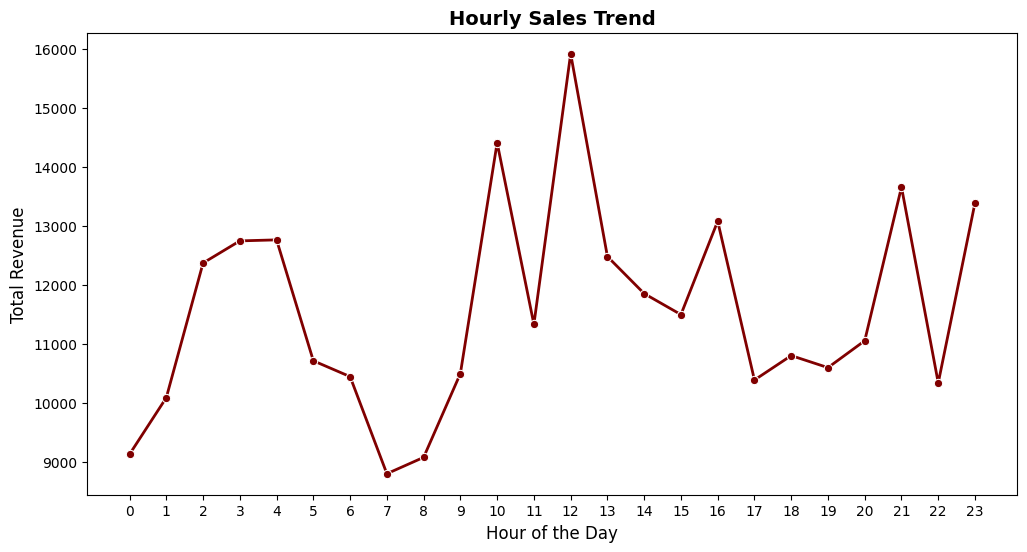

In [40]:
# Total revenue by each hour
hourly_sales = df1.groupby('hour')['revenue'].sum().reset_index()

# Plot line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_sales, x='hour', y='revenue', marker='o', color='maroon', linewidth=2)
plt.title('Hourly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day', fontsize = 12)
plt.ylabel('Total Revenue', fontsize = 12)

# To display 24 hours in the x-axis
plt.xticks(range(0, 24))

plt.show()

** Revenue peaks between (9 AM - 1 PM) and again during late hours between (9 PM - 11 PM) This suggest that users are most likely to puchase around mid-day.

### Revenue generated for each day during this time frame

In [41]:
df1.groupby('day')['revenue'].sum().sort_values(ascending = False)

,revenue
day,
Wednesday,49620.80
Tuesday,41421.61
Friday,40607.24
Saturday,39398.43
Thursday,38498.60
Sunday,35351.56
Monday,32424.82


** Wednesday generated highest revenue, while monday genereated the lowest.
Mid-week purchasing activity is significantly stronger than beginning of the week.

### Revenue over time (December 2025 - January 2026)

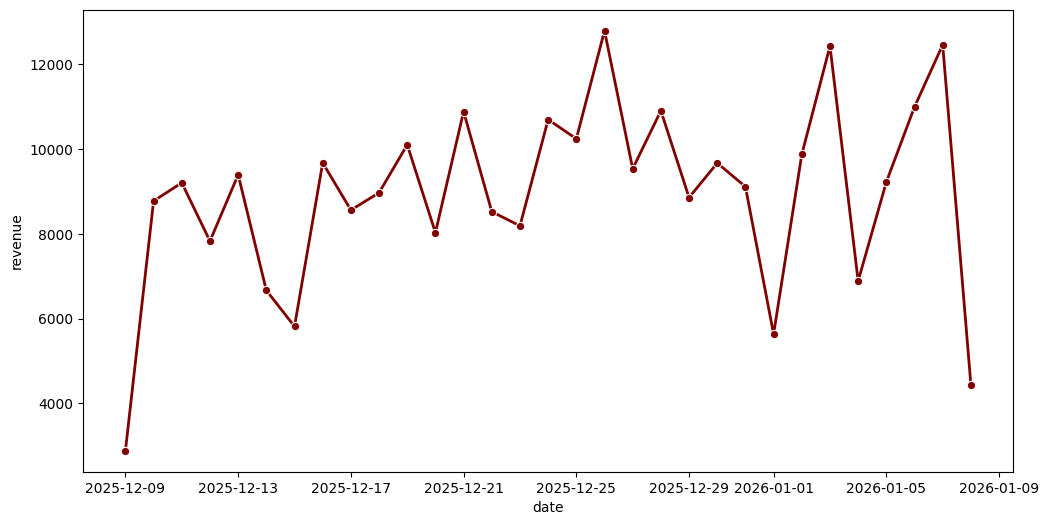

In [42]:
revenue_over_time = df1.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=revenue_over_time, x='date', y='revenue', marker='o', color='maroon', linewidth=2)
plt.show()

Daily Revenue seems stable within the time period, with strong performance during late december. While there are small dips, overall sales remains consistent, this indicates a steady customer demand throughout the period

In [45]:
### Exporting dataset with changes made ---
df1.to_csv('final_data.csv', index = False)